In [1]:
# Cell 1: Imports and style configuration

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("✓ Imports loaded successfully")

✓ Imports loaded successfully


In [2]:
# Cell 2: CONFIG — PASTE PATHS HERE

# ============================================================
# REQUIRED INPUT FILES (all 3 databases × 2 file types):
# - mixed_metrics_[DB].csv (throughput)
# - mixed_per_operation_[DB].csv (per-op latency)
# ============================================================

# ============================================================
# EDIT THESE SEVEN LINES
# ============================================================

# Supabase paths
supa_metrics_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Supa_results\Mixed\Data\mixed_metrics_Supabase.csv"
supa_per_op_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Supa_results\Mixed\Data\mixed_per_operation_Supabase.csv"

# MongoDB paths
mongo_metrics_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Mongo_results\Mixed\Data\mixed_metrics_MongoDB.csv"
mongo_per_op_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Mongo_results\Mixed\Data\mixed_per_operation_MongoDB.csv"

# AstraDB paths
astra_metrics_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Astra_results\Mixed\Data\mixed_metrics_AstraDB.csv"
astra_per_op_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Astra_results\Mixed\Data\mixed_per_operation_AstraDB.csv"

# Output folder
output_dir = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Mixed"

# ============================================================
# DO NOT EDIT BELOW
# ============================================================

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Output filenames
fig4a_filename = os.path.join(output_dir, "fig4a_mixed_throughput.png")
fig4b_filename = os.path.join(output_dir, "fig4b_mixed_per_op_p99.png")
fig4b_outlier_filename = os.path.join(output_dir, "fig4b_outliers_mixed_per_op_p99.png")

print("Input files:")
print("  Supabase metrics:", supa_metrics_csv)
print("  Supabase per-op:", supa_per_op_csv)
print("  MongoDB metrics:", mongo_metrics_csv)
print("  MongoDB per-op:", mongo_per_op_csv)
print("  AstraDB metrics:", astra_metrics_csv)
print("  AstraDB per-op:", astra_per_op_csv)
print("\nOutput folder:", output_dir)
print("\nFigures will be saved as:")
print("  Figure 4A:", fig4a_filename)
print("  Figure 4B:", fig4b_filename)
print("  Figure 4B Outliers (if needed):", fig4b_outlier_filename)

# Verify all inputs exist
missing = []
for label, path in [("Supabase metrics", supa_metrics_csv), 
                     ("Supabase per-op", supa_per_op_csv),
                     ("MongoDB metrics", mongo_metrics_csv),
                     ("MongoDB per-op", mongo_per_op_csv),
                     ("AstraDB metrics", astra_metrics_csv),
                     ("AstraDB per-op", astra_per_op_csv)]:
    if not os.path.exists(path):
        missing.append(label)

if missing:
    print(f"\n⚠️ MISSING FILES: {', '.join(missing)}")
else:
    print("\n✓ All input files found!")

Input files:
  Supabase metrics: C:\Users\avyaa\Desktop\Research Stuff\Results\Supa_results\Mixed\Data\mixed_metrics_Supabase.csv
  Supabase per-op: C:\Users\avyaa\Desktop\Research Stuff\Results\Supa_results\Mixed\Data\mixed_per_operation_Supabase.csv
  MongoDB metrics: C:\Users\avyaa\Desktop\Research Stuff\Results\Mongo_results\Mixed\Data\mixed_metrics_MongoDB.csv
  MongoDB per-op: C:\Users\avyaa\Desktop\Research Stuff\Results\Mongo_results\Mixed\Data\mixed_per_operation_MongoDB.csv
  AstraDB metrics: C:\Users\avyaa\Desktop\Research Stuff\Results\Astra_results\Mixed\Data\mixed_metrics_AstraDB.csv
  AstraDB per-op: C:\Users\avyaa\Desktop\Research Stuff\Results\Astra_results\Mixed\Data\mixed_per_operation_AstraDB.csv

Output folder: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Mixed

Figures will be saved as:
  Figure 4A: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Mixed\fig4a_mixed_throughput.png
  Figure 4B: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Mixe

In [3]:
# Cell 3: Load throughput and per-operation data

# Load database-level throughput metrics
df_supa_metrics = pd.read_csv(supa_metrics_csv)
df_mongo_metrics = pd.read_csv(mongo_metrics_csv)
df_astra_metrics = pd.read_csv(astra_metrics_csv)

# Load per-operation metrics
df_supa_ops = pd.read_csv(supa_per_op_csv)
df_mongo_ops = pd.read_csv(mongo_per_op_csv)
df_astra_ops = pd.read_csv(astra_per_op_csv)

# Validate throughput metrics columns
required_metrics = ["read_qps", "write_tps", "total_throughput_ops_sec"]
for name, df in [("Supabase", df_supa_metrics), ("MongoDB", df_mongo_metrics), ("AstraDB", df_astra_metrics)]:
    missing = [c for c in required_metrics if c not in df.columns]
    if missing:
        raise ValueError(f"{name} metrics missing columns: {missing}")

# Validate per-operation columns
required_ops = ["operation_id", "operation_type", "p99_ms"]
for name, df in [("Supabase", df_supa_ops), ("MongoDB", df_mongo_ops), ("AstraDB", df_astra_ops)]:
    missing = [c for c in required_ops if c not in df.columns]
    if missing:
        raise ValueError(f"{name} per-op missing columns: {missing}")

# Sort per-op data by operation_id
df_supa_ops = df_supa_ops.sort_values("operation_id").reset_index(drop=True)
df_mongo_ops = df_mongo_ops.sort_values("operation_id").reset_index(drop=True)
df_astra_ops = df_astra_ops.sort_values("operation_id").reset_index(drop=True)

# Verify all have same operations
operations = df_supa_ops["operation_id"].values
if not (np.array_equal(operations, df_mongo_ops["operation_id"].values) and 
        np.array_equal(operations, df_astra_ops["operation_id"].values)):
    print("⚠️ WARNING: Databases have different operation sets!")
    print("Using intersection of operations...")
    common = set(df_supa_ops["operation_id"]) & set(df_mongo_ops["operation_id"]) & set(df_astra_ops["operation_id"])
    operations = sorted(common)
    df_supa_ops = df_supa_ops[df_supa_ops["operation_id"].isin(operations)].sort_values("operation_id").reset_index(drop=True)
    df_mongo_ops = df_mongo_ops[df_mongo_ops["operation_id"].isin(operations)].sort_values("operation_id").reset_index(drop=True)
    df_astra_ops = df_astra_ops[df_astra_ops["operation_id"].isin(operations)].sort_values("operation_id").reset_index(drop=True)

print("✓ Data loaded and validated")
print(f"\nThroughput metrics:")
print(f"  Supabase: QPS={df_supa_metrics['read_qps'].iloc[0]:.2f}, TPS={df_supa_metrics['write_tps'].iloc[0]:.2f}")
print(f"  MongoDB: QPS={df_mongo_metrics['read_qps'].iloc[0]:.2f}, TPS={df_mongo_metrics['write_tps'].iloc[0]:.2f}")
print(f"  AstraDB: QPS={df_astra_metrics['read_qps'].iloc[0]:.2f}, TPS={df_astra_metrics['write_tps'].iloc[0]:.2f}")
print(f"\nPer-operation data:")
print(f"  Operations: {len(operations)} ({list(operations)})")

✓ Data loaded and validated

Throughput metrics:
  Supabase: QPS=1.89, TPS=1.02
  MongoDB: QPS=4.93, TPS=2.65
  AstraDB: QPS=2.07, TPS=1.11

Per-operation data:
  Operations: 11 (['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'W1', 'W2', 'W3', 'W4', 'W5'])



FIGURE 4A: THROUGHPUT COMPARISON
✓ Figure 4A saved: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Mixed\fig4a_mixed_throughput.png


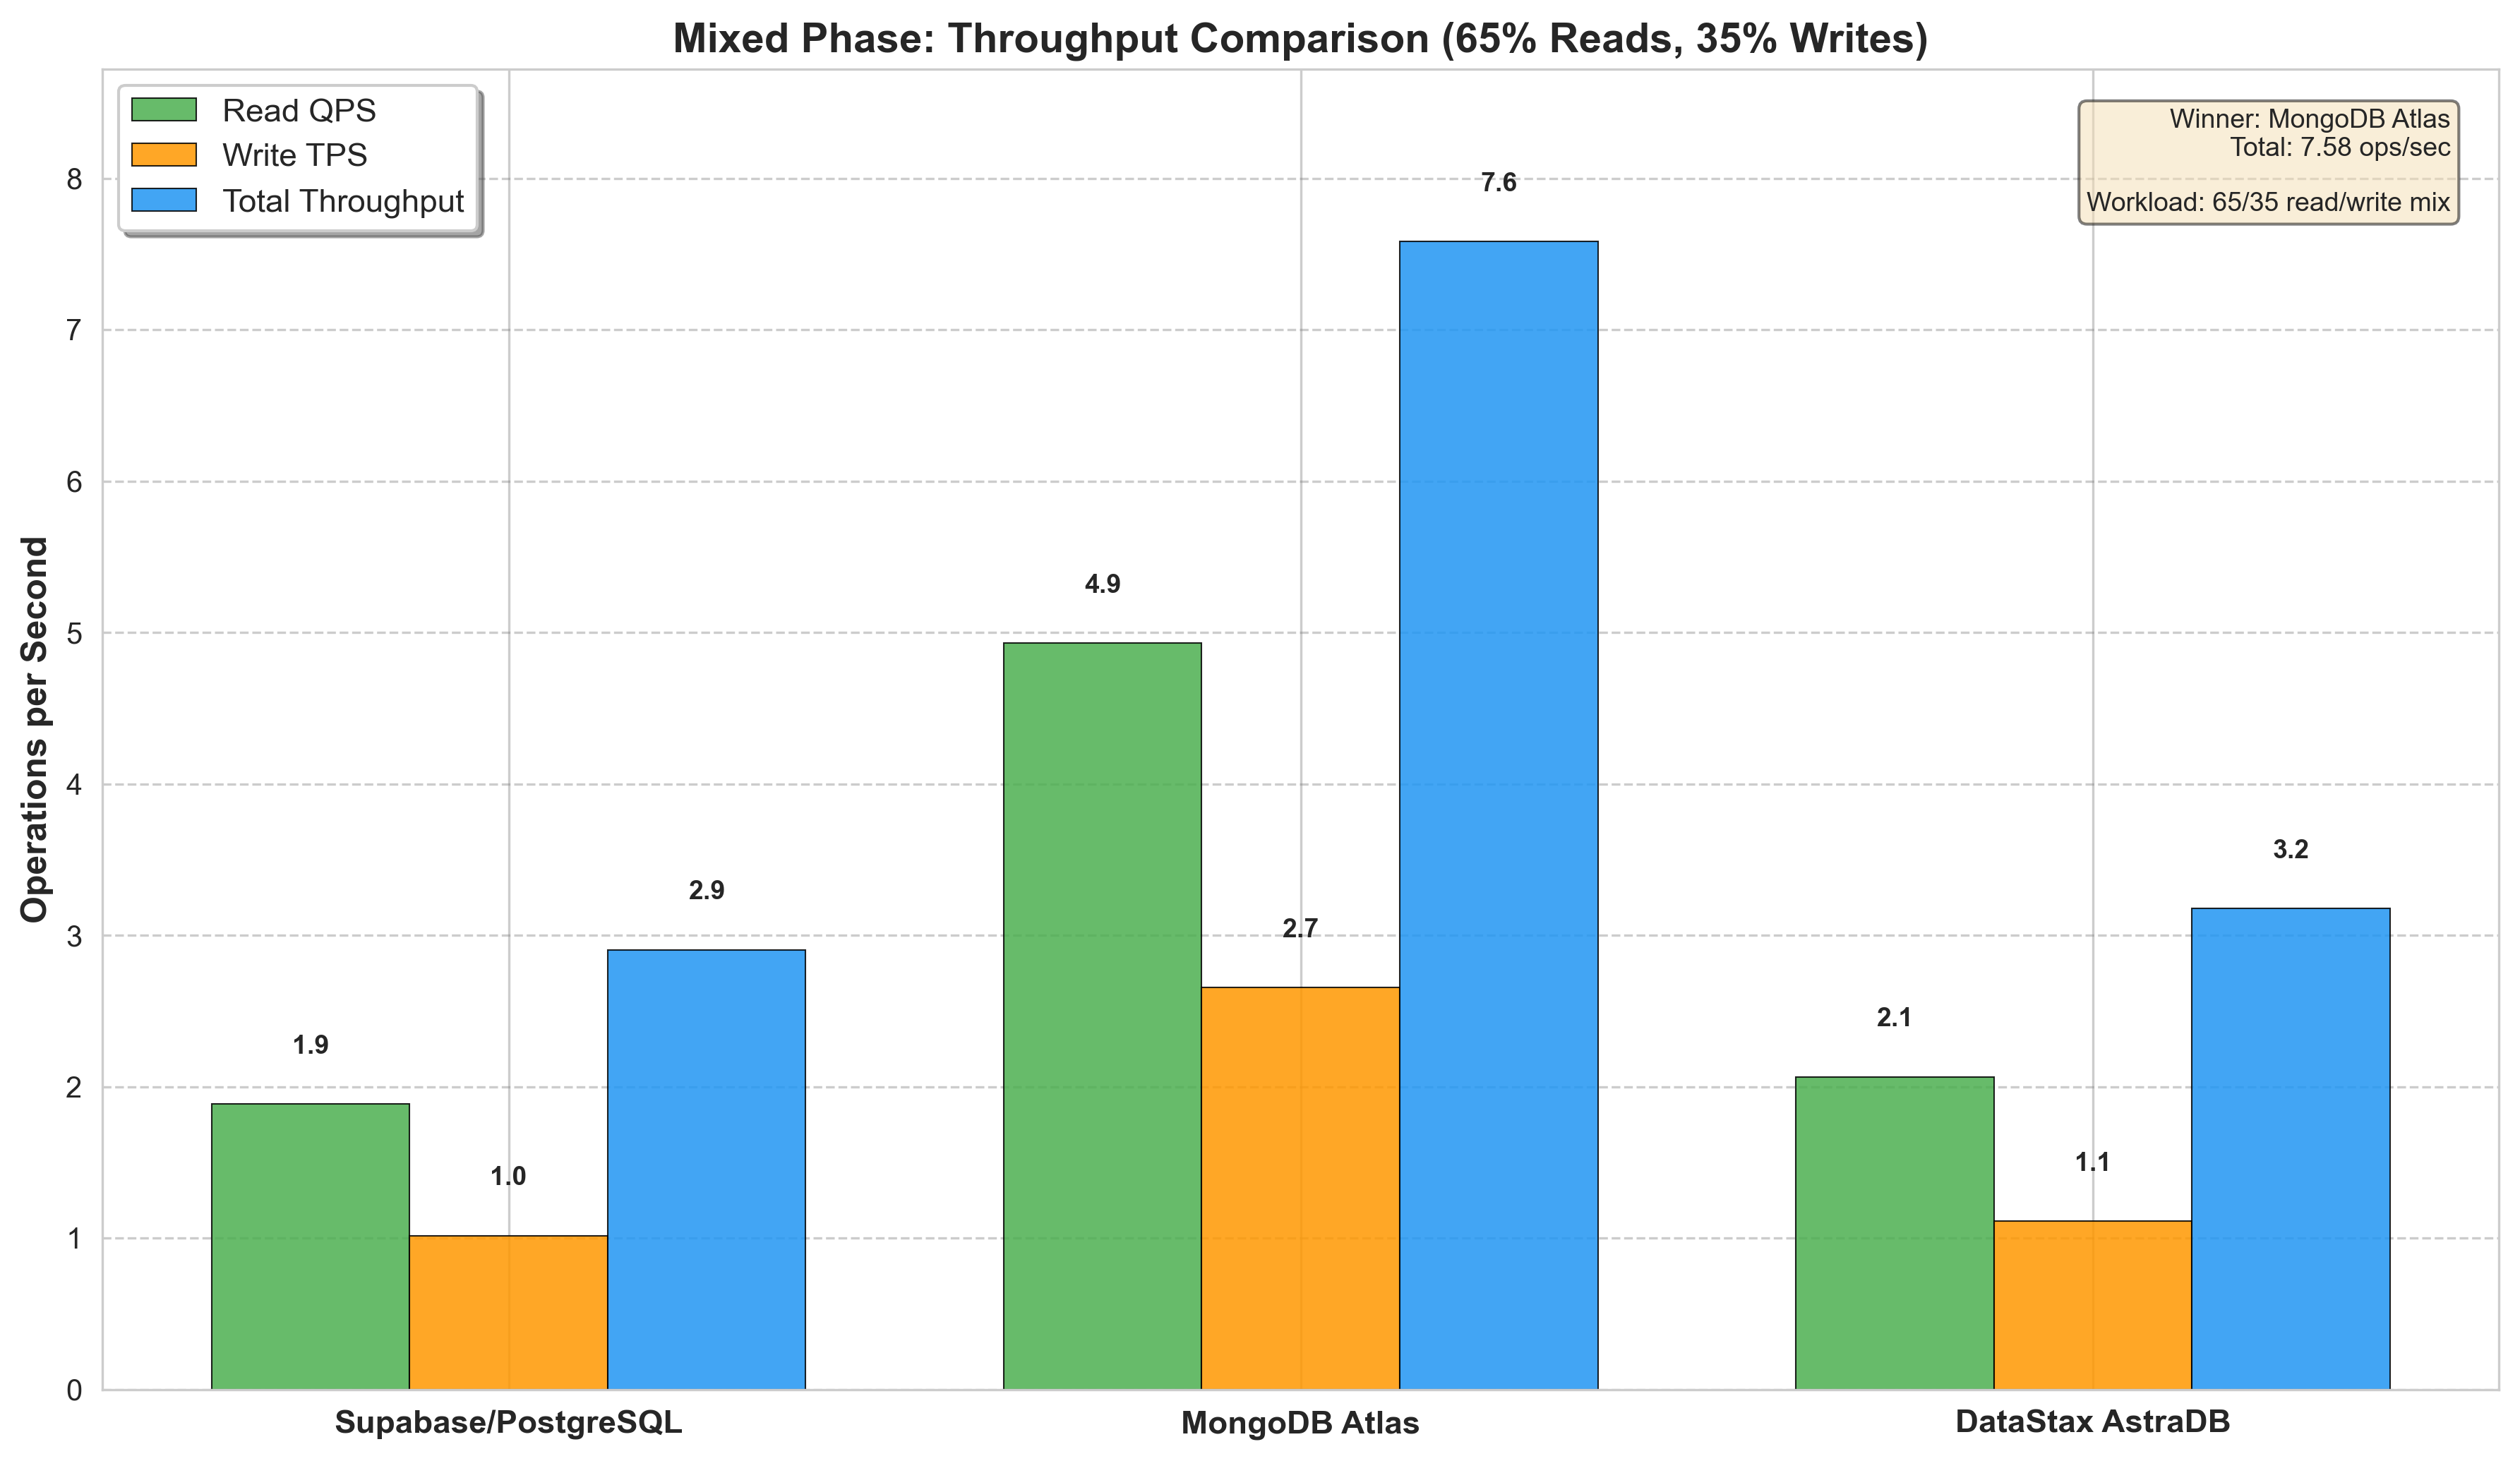

In [4]:
# Cell 4: Figure 4A - Throughput Comparison (QPS/TPS/Total)

print("\n" + "=" * 60)
print("FIGURE 4A: THROUGHPUT COMPARISON")
print("=" * 60)

fig, ax = plt.subplots(figsize=(12, 7))

# Extract throughput data
databases = ['Supabase/PostgreSQL', 'MongoDB Atlas', 'DataStax AstraDB']
qps_vals = [df_supa_metrics['read_qps'].iloc[0],
            df_mongo_metrics['read_qps'].iloc[0],
            df_astra_metrics['read_qps'].iloc[0]]
tps_vals = [df_supa_metrics['write_tps'].iloc[0],
            df_mongo_metrics['write_tps'].iloc[0],
            df_astra_metrics['write_tps'].iloc[0]]
total_vals = [df_supa_metrics['total_throughput_ops_sec'].iloc[0],
              df_mongo_metrics['total_throughput_ops_sec'].iloc[0],
              df_astra_metrics['total_throughput_ops_sec'].iloc[0]]

# Bar positioning
x = np.arange(len(databases))
width = 0.25

# Create grouped bars
bars1 = ax.bar(x - width, qps_vals, width, label='Read QPS', 
               color='#4CAF50', edgecolor='black', linewidth=0.5, alpha=0.85)
bars2 = ax.bar(x, tps_vals, width, label='Write TPS', 
               color='#FF9800', edgecolor='black', linewidth=0.5, alpha=0.85)
bars3 = ax.bar(x + width, total_vals, width, label='Total Throughput', 
               color='#2196F3', edgecolor='black', linewidth=0.5, alpha=0.85)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Y-axis limits
max_val = max(max(qps_vals), max(tps_vals), max(total_vals))
ax.set_ylim(0, max_val * 1.15)

# Axis properties
ax.set_ylabel('Operations per Second', fontweight='bold', fontsize=12)
ax.set_title('Mixed Phase: Throughput Comparison (65% Reads, 35% Writes)', 
             fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(databases, fontsize=11, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.8, color='gray')
ax.set_axisbelow(True)
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=11)

# Stats box
winner_idx = np.argmax(total_vals)
winner_db = databases[winner_idx]
stats_text = (
    f"Winner: {winner_db}\n"
    f"  Total: {total_vals[winner_idx]:.2f} ops/sec\n"
    f"\nWorkload: 65/35 read/write mix"
)
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5, edgecolor='black'))

plt.tight_layout()
plt.savefig(fig4a_filename, dpi=300, bbox_inches='tight')
print(f"✓ Figure 4A saved: {fig4a_filename}")
plt.show()

In [5]:
# Cell 5: Outlier Detection (Operation-Level p99)

print("\n" + "=" * 60)
print("OUTLIER DETECTION (Per-Operation p99)")
print("=" * 60)

# Combine all p99 values
all_p99 = np.concatenate([
    df_supa_ops["p99_ms"].values,
    df_mongo_ops["p99_ms"].values,
    df_astra_ops["p99_ms"].values
])

# Overall statistics
overall_median_p99 = np.nanmedian(all_p99)
overall_max_p99 = np.nanmax(all_p99)

print(f"Overall median p99: {overall_median_p99:.2f} ms")
print(f"Overall max p99: {overall_max_p99:.2f} ms")

# Detect outlier operations
outlier_ops = []
normal_ops = []

for i, op in enumerate(operations):
    # Get p99 values for this operation across all databases
    op_p99_vals = [
        df_supa_ops.iloc[i]["p99_ms"],
        df_mongo_ops.iloc[i]["p99_ms"],
        df_astra_ops.iloc[i]["p99_ms"]
    ]
    max_op_p99 = np.nanmax(op_p99_vals)
    
    # Flag if ANY database shows extreme p99 for this operation
    # Use 10× median OR 500ms absolute threshold (mixed workloads can have higher latency)
    if max_op_p99 > 10 * overall_median_p99 or max_op_p99 > 500:
        outlier_ops.append(op)
        print(f"\n🚨 OUTLIER OPERATION: {op}")
        print(f"   Max p99 across DBs: {max_op_p99:.2f} ms ({max_op_p99/overall_median_p99:.1f}× median p99)")
    else:
        normal_ops.append(op)

if len(outlier_ops) > 0:
    print(f"\n✓ Detected {len(outlier_ops)} outlier operation(s): {outlier_ops}")
    print(f"✓ Main figure will show {len(normal_ops)} normal operations")
else:
    print(f"\n✓ No extreme outliers detected")
    print(f"✓ All {len(operations)} operations in main figure")
    normal_ops = list(operations)

# Filter masks
mask_normal = [op in normal_ops for op in operations]
mask_outlier = [op in outlier_ops for op in operations]


OUTLIER DETECTION (Per-Operation p99)
Overall median p99: 346.48 ms
Overall max p99: 2947.91 ms

🚨 OUTLIER OPERATION: R1
   Max p99 across DBs: 706.44 ms (2.0× median p99)

🚨 OUTLIER OPERATION: R3
   Max p99 across DBs: 2947.91 ms (8.5× median p99)

🚨 OUTLIER OPERATION: R4
   Max p99 across DBs: 693.82 ms (2.0× median p99)

🚨 OUTLIER OPERATION: R5
   Max p99 across DBs: 1646.75 ms (4.8× median p99)

🚨 OUTLIER OPERATION: R6
   Max p99 across DBs: 741.56 ms (2.1× median p99)

🚨 OUTLIER OPERATION: W1
   Max p99 across DBs: 500.11 ms (1.4× median p99)

🚨 OUTLIER OPERATION: W4
   Max p99 across DBs: 1345.69 ms (3.9× median p99)

✓ Detected 7 outlier operation(s): ['R1', 'R3', 'R4', 'R5', 'R6', 'W1', 'W4']
✓ Main figure will show 4 normal operations



FIGURE 4B: PER-OPERATION P99
✓ Figure 4B saved: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Mixed\fig4b_mixed_per_op_p99.png


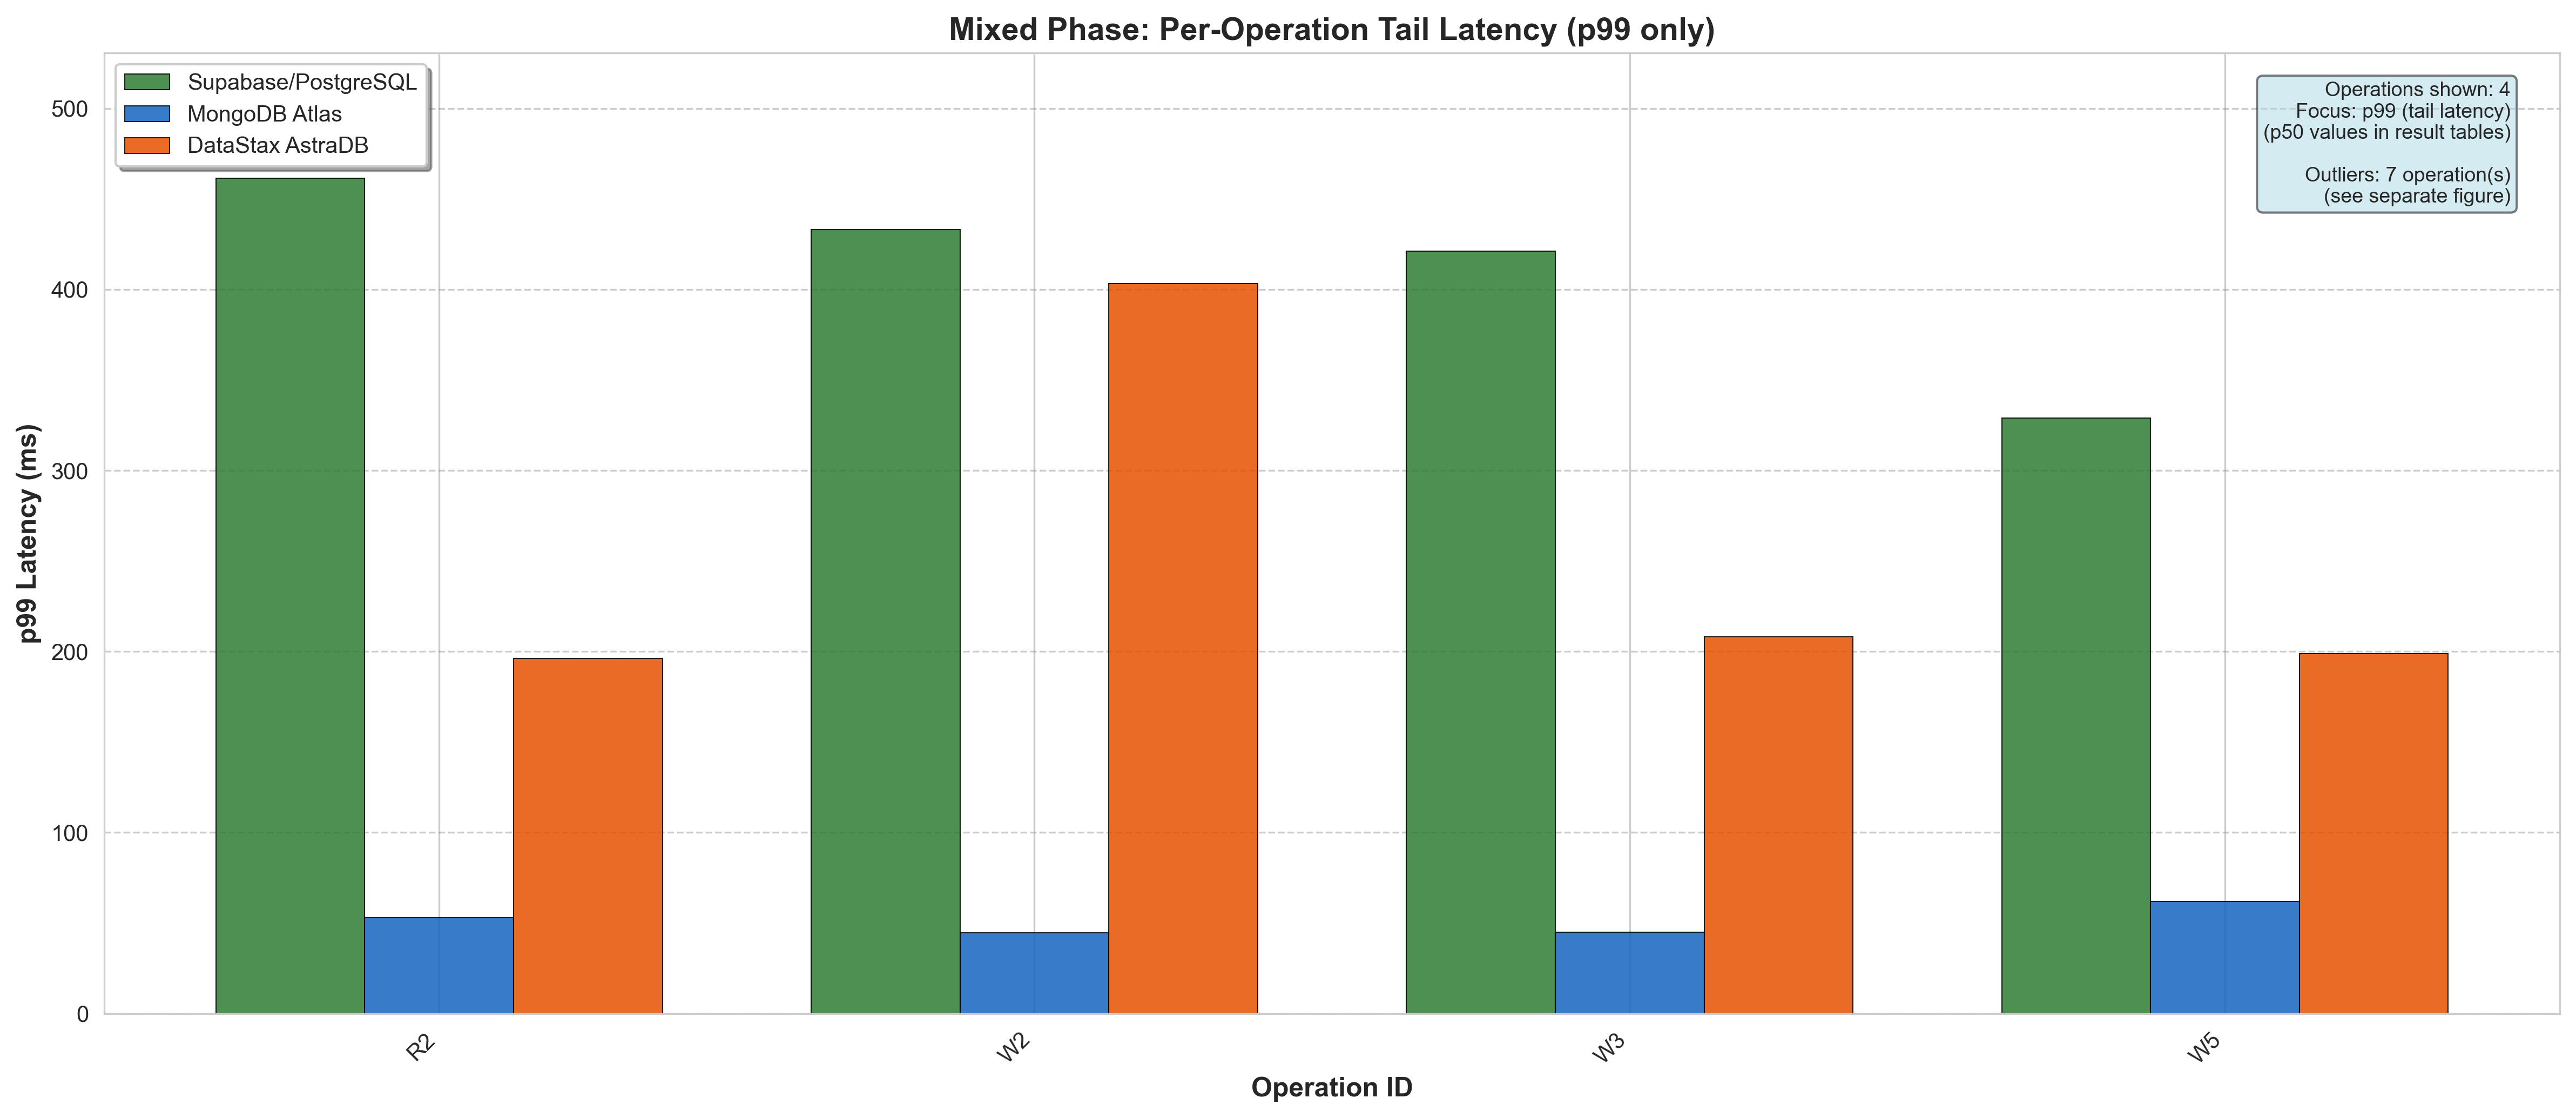

In [6]:
# Cell 6: Figure 4B - Per-Operation p99 Comparison (Normal Operations)

print("\n" + "=" * 60)
print("FIGURE 4B: PER-OPERATION P99")
print("=" * 60)

# Filter to normal operations
ops_normal = [op for op in operations if op in normal_ops]
n_ops_normal = len(ops_normal)

supa_p99_normal = df_supa_ops[mask_normal]["p99_ms"].values
mongo_p99_normal = df_mongo_ops[mask_normal]["p99_ms"].values
astra_p99_normal = df_astra_ops[mask_normal]["p99_ms"].values

fig, ax = plt.subplots(figsize=(16, 7))

# Bar positioning
x = np.arange(n_ops_normal)
width = 0.25

pos_supa = x - width
pos_mongo = x
pos_astra = x + width

# Create bars
ax.bar(pos_supa, supa_p99_normal, width, 
       label='Supabase/PostgreSQL', color='#2E7D32', 
       edgecolor='black', linewidth=0.5, alpha=0.85)
ax.bar(pos_mongo, mongo_p99_normal, width, 
       label='MongoDB Atlas', color='#1565C0', 
       edgecolor='black', linewidth=0.5, alpha=0.85)
ax.bar(pos_astra, astra_p99_normal, width, 
       label='DataStax AstraDB', color='#E65100', 
       edgecolor='black', linewidth=0.5, alpha=0.85)

# Adaptive Y-axis
all_p99_normal = np.concatenate([supa_p99_normal, mongo_p99_normal, astra_p99_normal])
max_val = np.nanmax(all_p99_normal)
y_range = max_val

if y_range < 20:
    padding = 10
elif y_range < 100:
    padding = 20
else:
    padding = max_val * 0.15

y_limit = max_val + padding

# Axis properties
ax.set_xlabel('Operation ID', fontweight='bold', fontsize=12)
ax.set_ylabel('p99 Latency (ms)', fontweight='bold', fontsize=12)
ax.set_title('Mixed Phase: Per-Operation Tail Latency (p99 only)', 
             fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(ops_normal, fontsize=10, rotation=45, ha='right')
ax.set_ylim(0, y_limit)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.8, color='gray')
ax.set_axisbelow(True)
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)

# Stats box
stats_text = (
    f"Operations shown: {n_ops_normal}\n"
    f"Focus: p99 (tail latency)\n"
    f"(p50 values in result tables)"
)
if len(outlier_ops) > 0:
    stats_text += f"\n\nOutliers: {len(outlier_ops)} operation(s)\n(see separate figure)"

ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5, edgecolor='black'))

plt.tight_layout()
plt.savefig(fig4b_filename, dpi=300, bbox_inches='tight')
print(f"✓ Figure 4B saved: {fig4b_filename}")
plt.show()


OUTLIER FIGURE GENERATION
✓ Outlier figure saved: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Mixed\fig4b_outliers_mixed_per_op_p99.png


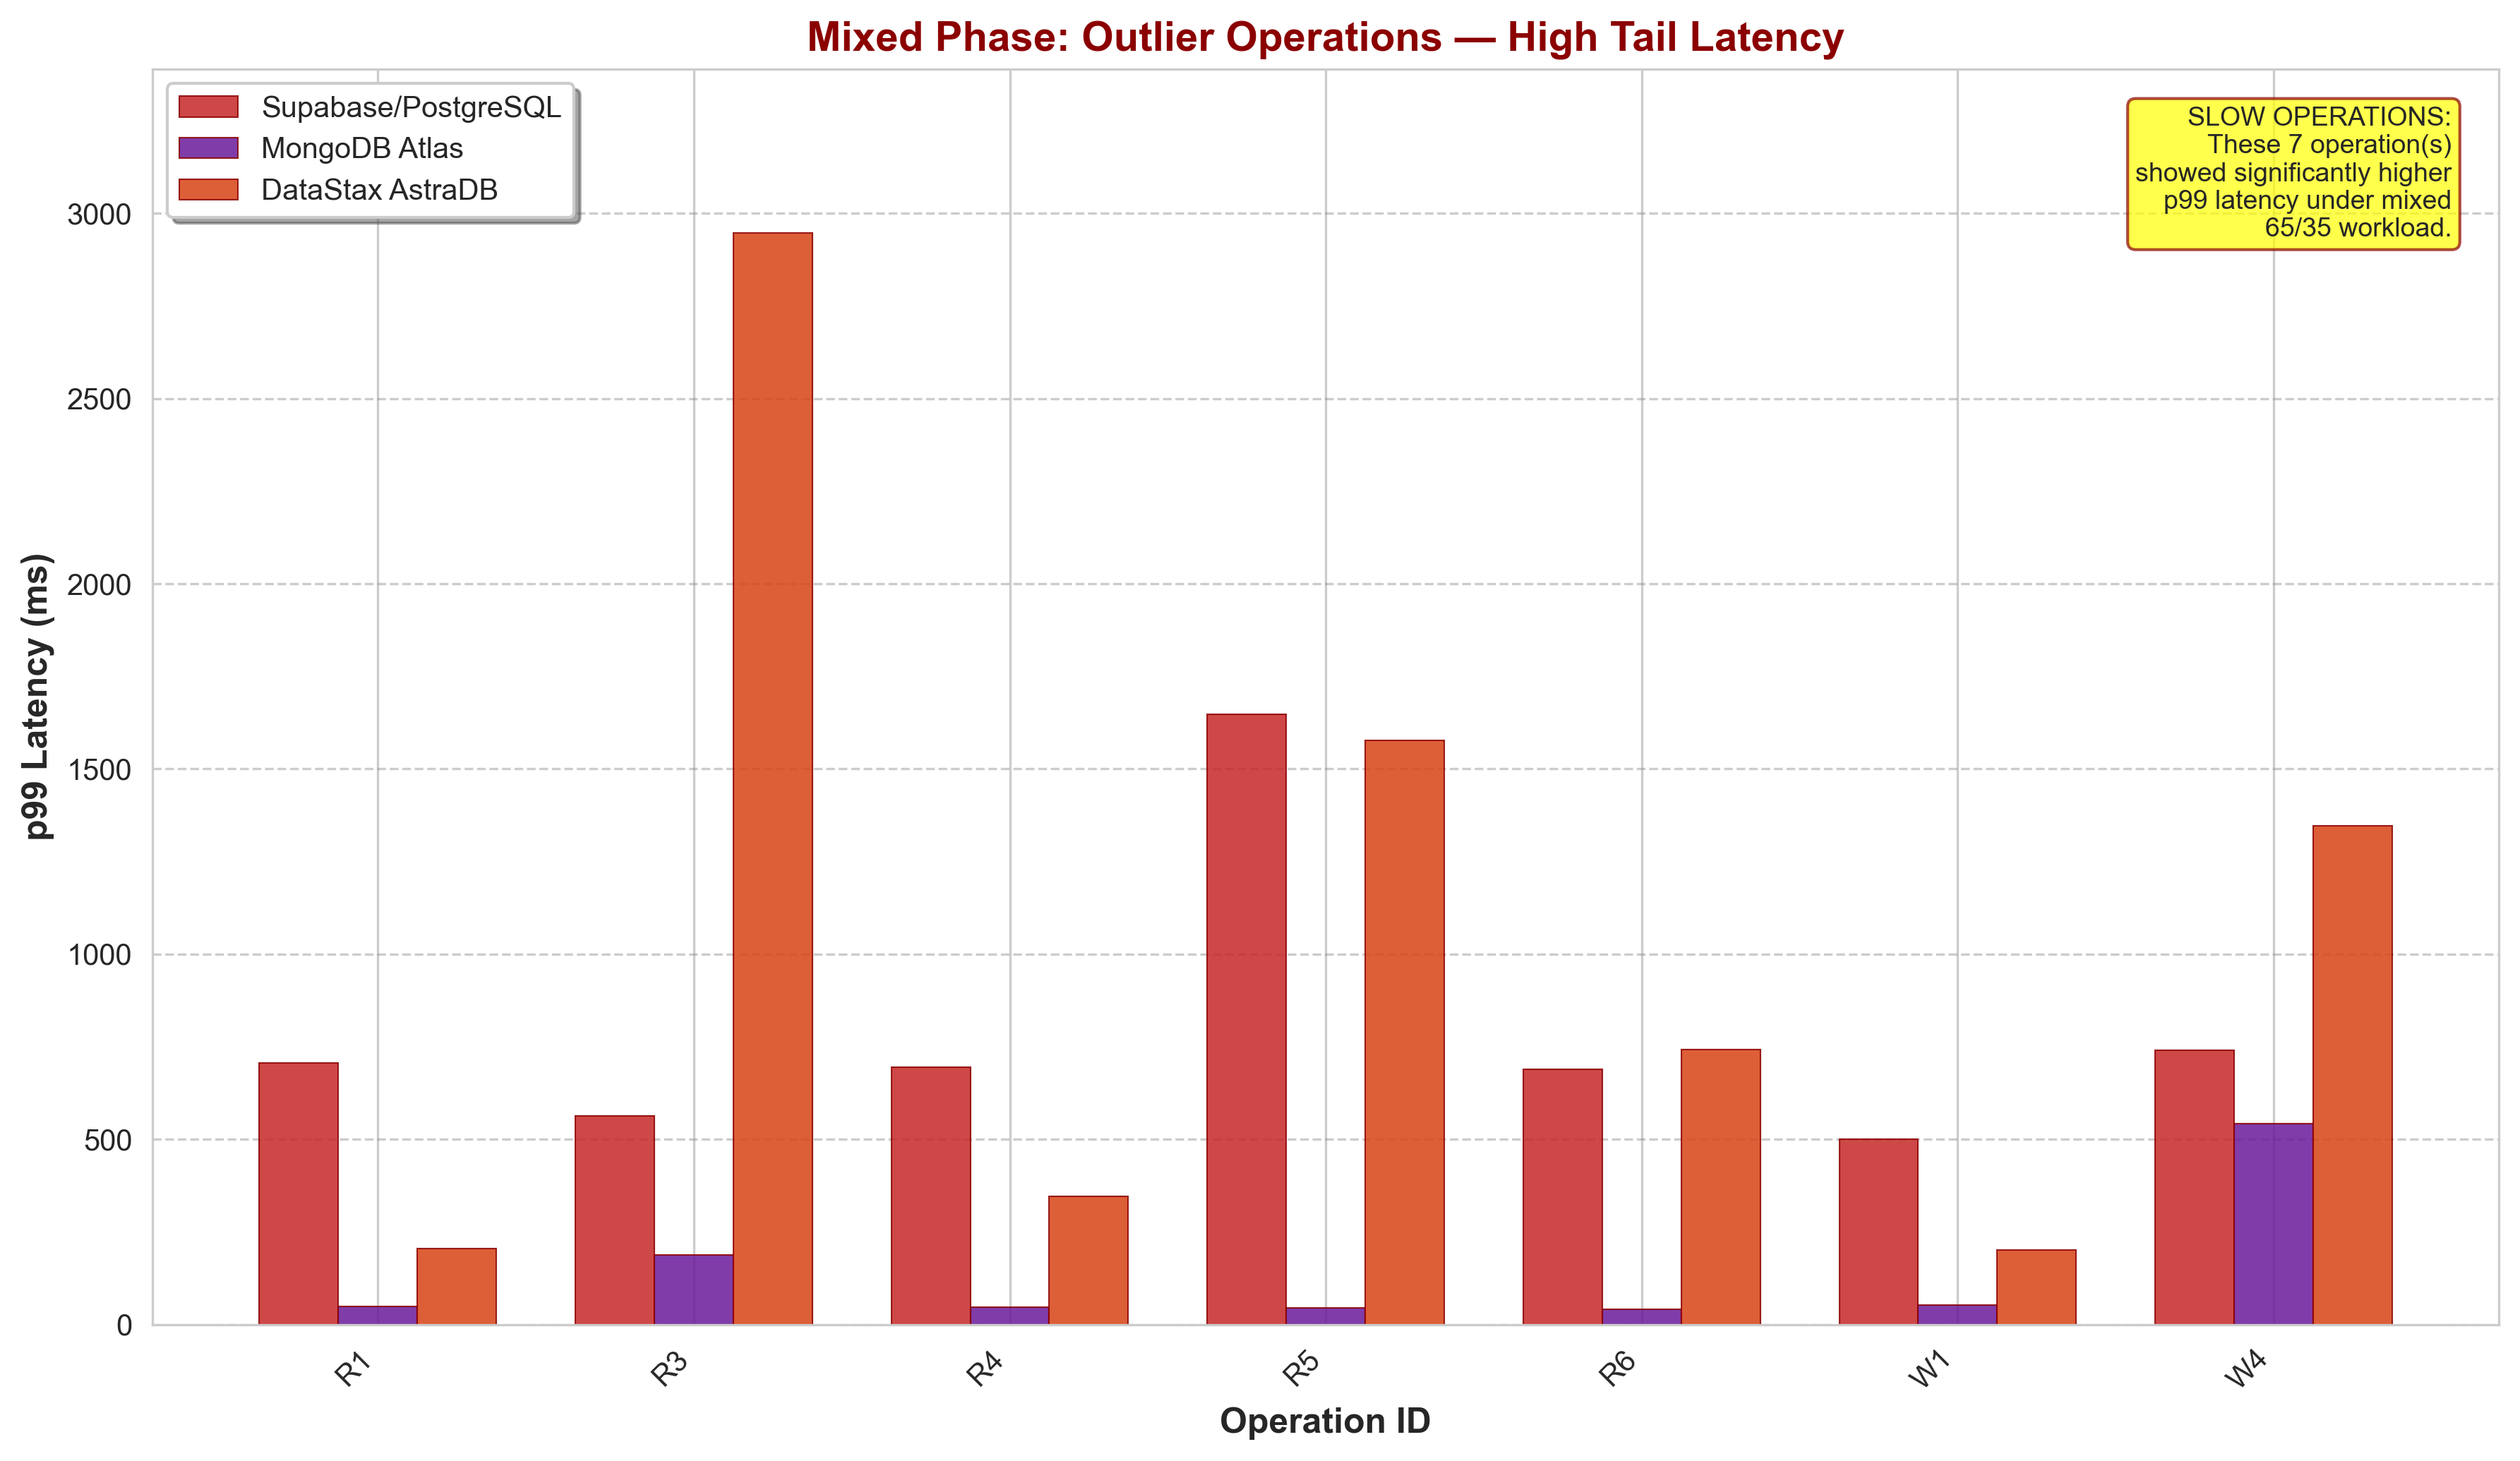

In [7]:
# Cell 7: Figure 4B Outliers - Separate visualization if outliers exist

if len(outlier_ops) > 0:
    print("\n" + "=" * 60)
    print("OUTLIER FIGURE GENERATION")
    print("=" * 60)
    
    # Filter to outlier operations
    ops_outlier = [op for op in operations if op in outlier_ops]
    n_ops_outlier = len(ops_outlier)
    
    supa_p99_outlier = df_supa_ops[mask_outlier]["p99_ms"].values
    mongo_p99_outlier = df_mongo_ops[mask_outlier]["p99_ms"].values
    astra_p99_outlier = df_astra_ops[mask_outlier]["p99_ms"].values
    
    fig_out, ax_out = plt.subplots(figsize=(12, 7))
    
    # Bar positioning
    x_out = np.arange(n_ops_outlier)
    width = 0.25
    
    pos_supa = x_out - width
    pos_mongo = x_out
    pos_astra = x_out + width
    
    # Create bars (RED scheme)
    ax_out.bar(pos_supa, supa_p99_outlier, width, 
               label='Supabase/PostgreSQL', color='#C62828', 
               edgecolor='darkred', linewidth=0.5, alpha=0.85)
    ax_out.bar(pos_mongo, mongo_p99_outlier, width, 
               label='MongoDB Atlas', color='#6A1B9A', 
               edgecolor='darkred', linewidth=0.5, alpha=0.85)
    ax_out.bar(pos_astra, astra_p99_outlier, width, 
               label='DataStax AstraDB', color='#D84315', 
               edgecolor='darkred', linewidth=0.5, alpha=0.85)
    
    # Y-axis limits
    all_p99_outlier = np.concatenate([supa_p99_outlier, mongo_p99_outlier, astra_p99_outlier])
    out_max = np.nanmax(all_p99_outlier)
    out_min = np.nanmin(all_p99_outlier)
    
    # Use log scale if extreme
    if out_max / max(out_min, 1) > 100:
        ax_out.set_yscale('log')
        ylabel = 'p99 Latency (ms) — LOG SCALE'
        print(f"  Using log scale (range: {out_min:.2f} to {out_max:.2f} ms)")
    else:
        ylabel = 'p99 Latency (ms)'
        ax_out.set_ylim(0, out_max * 1.15)
    
    # Axis properties
    ax_out.set_xlabel('Operation ID', fontweight='bold', fontsize=12)
    ax_out.set_ylabel(ylabel, fontweight='bold', fontsize=12)
    ax_out.set_title('Mixed Phase: Outlier Operations — High Tail Latency', 
                     fontweight='bold', fontsize=14, color='darkred')
    ax_out.set_xticks(x_out)
    ax_out.set_xticklabels(ops_outlier, fontsize=10, rotation=45, ha='right')
    ax_out.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.8, color='gray')
    ax_out.set_axisbelow(True)
    ax_out.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
    
    # Warning box
    warn_text = (
        f"SLOW OPERATIONS:\n"
        f"These {n_ops_outlier} operation(s)\n"
        f"showed significantly higher\n"
        f"p99 latency under mixed\n"
        f"65/35 workload."
    )
    ax_out.text(0.98, 0.97, warn_text, transform=ax_out.transAxes,
                fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7, edgecolor='darkred'))
    
    plt.tight_layout()
    plt.savefig(fig4b_outlier_filename, dpi=300, bbox_inches='tight')
    print(f"✓ Outlier figure saved: {fig4b_outlier_filename}")
    plt.show()
else:
    print("\n✓ No outliers detected — skipping outlier figure")

In [8]:
# Cell 8: Summary

print("\n" + "=" * 60)
print("MIXED FIGURES GENERATION COMPLETE")
print("=" * 60)

print(f"\n📊 Databases processed: Supabase, MongoDB, AstraDB")
print(f"📁 Figures saved to: {output_dir}\n")

print(f"  Figure 4A: {os.path.basename(fig4a_filename)}")
print(f"    └─ Throughput comparison (QPS/TPS/Total)")

if len(outlier_ops) > 0:
    print(f"  Figure 4B (Main): {os.path.basename(fig4b_filename)}")
    print(f"    └─ {len(normal_ops)} normal operations (p99 only)")
    print(f"  Figure 4B (Outliers): {os.path.basename(fig4b_outlier_filename)}")
    print(f"    └─ {len(outlier_ops)} outlier operation(s): {outlier_ops}")
else:
    print(f"  Figure 4B: {os.path.basename(fig4b_filename)}")
    print(f"    └─ All {len(operations)} operations (p99 only, no outliers)")

print("\n✓ All figures generated successfully!")
print("\n📌 Key insights to look for:")
print("  - Figure 4A: Which database has best overall throughput?")
print("  - Figure 4B: Which operations dominate tail latency under mixed load?")
if len(outlier_ops) > 0:
    print("  - Outlier figure: Why these operations slow under 65/35 mix?")


MIXED FIGURES GENERATION COMPLETE

📊 Databases processed: Supabase, MongoDB, AstraDB
📁 Figures saved to: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Mixed

  Figure 4A: fig4a_mixed_throughput.png
    └─ Throughput comparison (QPS/TPS/Total)
  Figure 4B (Main): fig4b_mixed_per_op_p99.png
    └─ 4 normal operations (p99 only)
  Figure 4B (Outliers): fig4b_outliers_mixed_per_op_p99.png
    └─ 7 outlier operation(s): ['R1', 'R3', 'R4', 'R5', 'R6', 'W1', 'W4']

✓ All figures generated successfully!

📌 Key insights to look for:
  - Figure 4A: Which database has best overall throughput?
  - Figure 4B: Which operations dominate tail latency under mixed load?
  - Outlier figure: Why these operations slow under 65/35 mix?
